# Import Library

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
print("My numpy version is: ", np.__version__)

My numpy version is:  1.26.4


# Membaca Dataset

In [3]:
df= pd.read_csv('news.csv')

In [4]:
df

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL
...,...,...,...,...
6330,4490,State Department says it can't find emails fro...,The State Department told the Republican Natio...,REAL
6331,8062,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,FAKE
6332,8622,Anti-Trump Protesters Are Tools of the Oligarc...,Anti-Trump Protesters Are Tools of the Oligar...,FAKE
6333,4021,"In Ethiopia, Obama seeks progress on peace, se...","ADDIS ABABA, Ethiopia —President Obama convene...",REAL


## Dataframe Head

In [5]:
df.head()

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


## Dataframe Tail

In [6]:
df.tail()

,Unnamed: 0,title,text,label
6330,4490,State Department says it can't find emails fro...,The State Department told the Republican Natio...,REAL
6331,8062,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,FAKE
6332,8622,Anti-Trump Protesters Are Tools of the Oligarc...,Anti-Trump Protesters Are Tools of the Oligar...,FAKE
6333,4021,"In Ethiopia, Obama seeks progress on peace, se...","ADDIS ABABA, Ethiopia —President Obama convene...",REAL
6334,4330,Jeb Bush Is Suddenly Attacking Trump. Here's W...,Jeb Bush Is Suddenly Attacking Trump. Here's W...,REAL


## Dataframe Info

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  6335 non-null   int64 
 1   title       6335 non-null   object
 2   text        6335 non-null   object
 3   label       6335 non-null   object
dtypes: int64(1), object(3)
memory usage: 198.1+ KB


## Dataframe Shape

In [8]:
df.shape

(6335, 4)

## Dataframe Column

In [9]:
df.columns

Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')

## Cek Jumlah NaN

In [10]:
hitung_nan = df.isna().sum()
hitung_nan

Unnamed: 0    0
title         0
text          0
label         0
dtype: int64

## Cek Kolom Null

In [11]:
df_null = df.isnull().values.any()
df_null

False

# EDA & Preprocessing

In [12]:
# check the distribution of labels
df['label'].value_counts()

label
REAL    3171
FAKE    3164
Name: count, dtype: int64

## Grafik Distribusi

Text(0.5, 1.0, 'Grafik Distribusi Label')

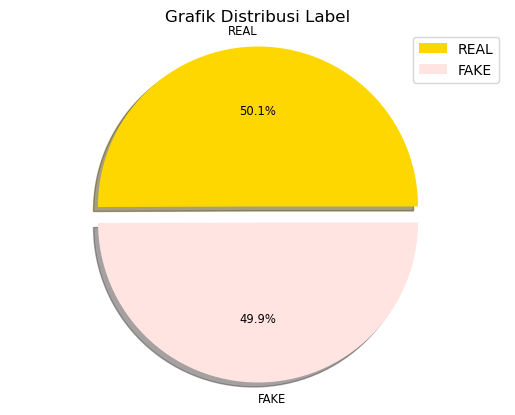

In [13]:
fig,ax = plt.subplots()
ax.pie(df['label'].value_counts(), explode={0,0.1},labels=df['label'].value_counts().index,autopct='%1.1f%%',colors=['gold','mistyrose'],shadow=True,textprops={'size': 'smaller'})
ax.axis('equal')
ax.legend()
ax.set_title('Grafik Distribusi Label')

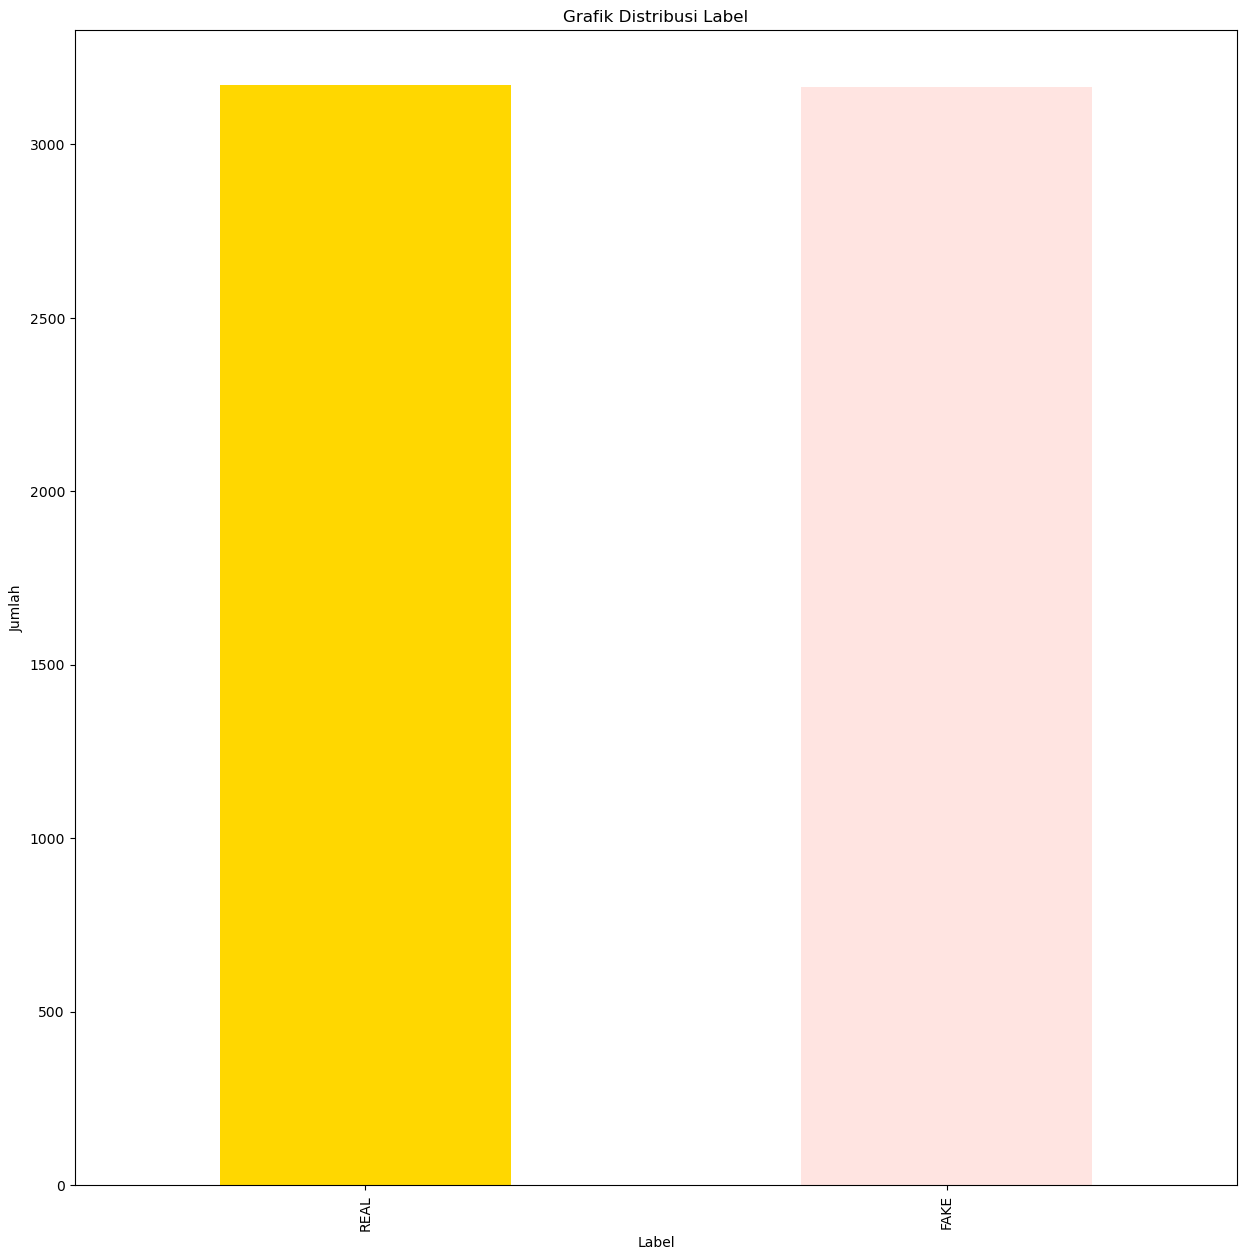

In [14]:
ax = df['label'].value_counts().plot(kind='bar',color=['gold','mistyrose'], figsize=(15,15))
ax.set_title('Grafik Distribusi Label')
ax.set_ylabel('Jumlah')
ax.set_xlabel('Label')
plt.show()

Dari uraian di atas, kita dapat melihat bahwa hampir semua label (kelas) muncul dalam jumlah yang sama dan seimbang. Sekarang kita akan menambah kolom baru untuk mengkonversi nilai kolom LABEL = FALSE, akan menjadi 0. Jika nilai kolom LABEL = TRUE, akan menjadi 1. Hal ini nanti akan menjadi bahan pengukuran kesamaan antara kata-kata. Dengan menggunakan representasi numerik dari kata-kata, kita dapat menghitung seberapa mirip dua kata berdasarkan konteks dan makna mereka. Ini berguna untuk menemukan sinonim atau kata-kata yang terkait. Library yang akan digunakan adalah Spacy.

## Kolom Baru
Nama kolom baru yang menampung hasil konversi adalah label_num

In [15]:
# Add the new column which gives a unique number to each of these labels
df['label_num'] = df['label'].map({'FAKE' : 0, 'REAL': 1})

# check the results with top 5 rows
df.head(5)

,Unnamed: 0,title,text,label,label_num
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE,0
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE,0
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL,1
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE,0
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL,1


In [16]:
!pip show spacy

Name: spacy
Version: 3.7.2
Summary: Industrial-strength Natural Language Processing (NLP) in Python
Home-page: https://spacy.io
Author: Explosion
Author-email: contact@explosion.ai
License: MIT
Location: /opt/anaconda3/lib/python3.12/site-packages
Requires: catalogue, cymem, jinja2, langcodes, murmurhash, numpy, packaging, preshed, pydantic, requests, setuptools, smart-open, spacy-legacy, spacy-loggers, srsly, thinc, tqdm, typer, wasabi, weasel
Required-by: en-core-web-md


In [17]:
import spacy
nlp = spacy.load("en_core_web_md")

In [18]:
df['vector'] = df['text'].apply(lambda text: nlp(text).vector)

In [19]:
df.head()

,Unnamed: 0,title,text,label,label_num,vector
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE,0,"[-1.3628423, 1.3301896, -2.4013436, 0.15599144..."
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE,0,"[-1.7456636, 0.9506303, -2.0642009, 0.42432088..."
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL,1,"[-1.9492646, 0.98800147, -2.0101316, 0.2007011..."
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE,0,"[-1.9412395, -0.108313225, -1.1697294, 0.74054..."
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL,1,"[-1.8670002, 1.3043079, -2.1585224, 1.2115777,..."


In [20]:
df

,Unnamed: 0,title,text,label,label_num,vector
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE,0,"[-1.3628423, 1.3301896, -2.4013436, 0.15599144..."
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE,0,"[-1.7456636, 0.9506303, -2.0642009, 0.42432088..."
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL,1,"[-1.9492646, 0.98800147, -2.0101316, 0.2007011..."
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE,0,"[-1.9412395, -0.108313225, -1.1697294, 0.74054..."
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL,1,"[-1.8670002, 1.3043079, -2.1585224, 1.2115777,..."
...,...,...,...,...,...,...
6330,4490,State Department says it can't find emails fro...,The State Department told the Republican Natio...,REAL,1,"[-1.5480009, 0.64828396, -1.1199322, 0.1819167..."
6331,8062,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,FAKE,0,"[-2.1922188, -0.15432613, -1.0950338, 0.681122..."
6332,8622,Anti-Trump Protesters Are Tools of the Oligarc...,Anti-Trump Protesters Are Tools of the Oligar...,FAKE,0,"[-2.5719495, 0.47602493, -1.8889282, 0.8357609..."
6333,4021,"In Ethiopia, Obama seeks progress on peace, se...","ADDIS ABABA, Ethiopia —President Obama convene...",REAL,1,"[-1.8804584, 0.67208505, -1.9855198, 0.4335258..."


## Split Data

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.vector.values,
    df.label_num,
    test_size=0.2,
    random_state=2022
)

In [22]:
X_train_2d = np.stack(X_train)
X_test_2d = np.stack(X_test)

## Data Scalling

In [23]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_train_embed = scaler.fit_transform(X_train_2d)
scaled_test_embed = scaler.transform(X_test_2d)

# Model

## Naive Bayes Model

In [24]:
from sklearn.naive_bayes import MultinomialNB

clf = MultinomialNB()
clf.fit(scaled_train_embed, y_train)

MultinomialNB()

In [25]:
from sklearn.metrics import classification_report
y_pred = clf.predict(scaled_test_embed)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.69      0.75       634
           1       0.73      0.86      0.79       633

    accuracy                           0.77      1267
   macro avg       0.78      0.77      0.77      1267
weighted avg       0.78      0.77      0.77      1267



## KNN Model

In [26]:
from  sklearn.neighbors import KNeighborsClassifier

#1. creating a KNN model object
clf = KNeighborsClassifier(n_neighbors = 5, metric = 'euclidean')

#2. fit with all_train_embeddings and y_train
clf.fit(X_train_2d, y_train)

#3. get the predictions for all_test_embeddings and store it in y_pred
y_pred = clf.predict(X_test_2d)

#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.76      0.82       634
           1       0.79      0.92      0.85       633

    accuracy                           0.84      1267
   macro avg       0.85      0.84      0.84      1267
weighted avg       0.85      0.84      0.84      1267



# Confussion Matrix

Text(95.72222222222221, 0.5, 'Truth')

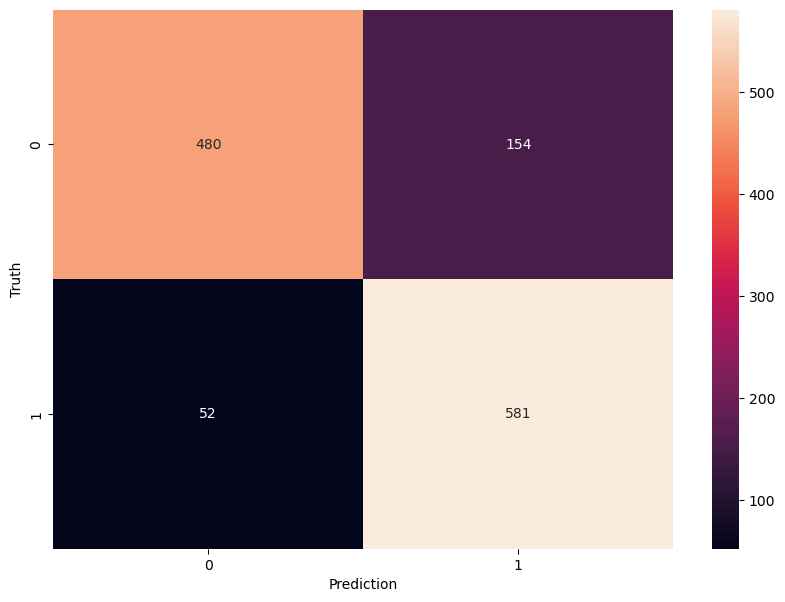

In [27]:
#finally print the confusion matrix for the best model
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

from matplotlib import pyplot as plt
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Truth')

Poin-poin Penting
Model KNN yang tidak berkinerja baik dalam teknik vektorisasi seperti Bag of words, dan TF-IDF karena ruang vektor berdimensi sangat tinggi, berkinerja sangat baik dengan vektor glove karena hanya memiliki vektor 300 dimensi dan embedding yang sangat baik (kata-kata yang mirip dan terkait memiliki embedding yang hampir serupa) untuk data teks yang diberikan.

Model MultinomialNB berkinerja cukup baik tetapi tidak masuk dalam daftar teratas karena dalam vektor 300 dimensi kami juga memiliki nilai negatif. Model Naive Bayes tidak sesuai dengan data jika ada nilai negatif. Jadi, untuk mengatasi kekurangan ini, kami telah menggunakan Min-Max scaler untuk menurunkan semua nilai antara 0 hingga 1. Dalam proses ini, akan ada kemungkinan varians dan kehilangan informasi di antara data. Namun, kami mendapatkan recall dan skor f1 yang layak.